# 02 Modeling Baseline

Week 3 baseline modeling notebook for predicting California residential single-family property `ClosePrice`.

This notebook builds directly on the Week 2 EDA and focuses on:

1. Rebuilding the scoped dataset from the monthly raw files.
2. Cleaning suspicious rows for modeling.
3. Engineering practical baseline features.
4. Training and comparing several baseline regression models.
5. Visualizing performance, residual patterns, and feature importance.


## Week 3 Goal

The goal is not to find the final production model yet. The goal is to create a solid baseline that answers:

- Can the current data support meaningful price prediction?
- Which features matter most in the first pass?
- Where do the biggest prediction errors appear?

This baseline gives us a reference point for later tuning and feature expansion.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import TransformedTargetRegressor

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("ggplot")
RANDOM_STATE = 42


## Load And Combine Monthly Raw Files

The notebook assumes it lives inside the repository's `notebooks/` folder, so the raw files are expected in `../data/raw/`.


In [2]:
raw_dir = Path("../data/raw")
raw_files = sorted(raw_dir.glob("CRMLSSold*.csv"))

if not raw_files:
    raise FileNotFoundError("No raw CSV files were found in ../data/raw")

frames = []
for file_path in raw_files:
    month_tag = file_path.stem.replace("CRMLSSold", "")
    monthly_df = pd.read_csv(file_path, low_memory=False)
    monthly_df["source_file"] = file_path.name
    monthly_df["source_month"] = month_tag
    frames.append(monthly_df)

raw_df = pd.concat(frames, ignore_index=True)

print(f"Loaded {len(raw_files)} files")
print(f"Raw shape: {raw_df.shape}")
display(pd.DataFrame({"file": [p.name for p in raw_files]}))


Loaded 7 files
Raw shape: (143492, 80)


,file
0,CRMLSSold202511.csv
1,CRMLSSold202512.csv
2,CRMLSSold202601.csv
3,CRMLSSold202602.csv
4,CRMLSSold202603.csv
5,CRMLSSold202604.csv
6,CRMLSSold202605.csv


## Rebuild The Week 2 Scoped Dataset

We keep:

- `PropertyType == "Residential"`
- `PropertySubType == "SingleFamilyResidence"`

We also remove duplicate listing records using the same identifier strategy as the Week 2 notebook.


In [ ]:
scoped_df = raw_df.loc[
    (raw_df["PropertyType"] == "Residential")
    & (raw_df["PropertySubType"] == "SingleFamilyResidence")
].copy()

scoped_df["dedupe_key"] = (
    scoped_df["ListingKeyNumeric"].astype("string").fillna("").str.strip()
)

mask = scoped_df["dedupe_key"].eq("")
scoped_df.loc[mask, "dedupe_key"] = (
    scoped_df.loc[mask, "ListingId"].astype("string").fillna("").str.strip()
)

mask = scoped_df["dedupe_key"].eq("")
scoped_df.loc[mask, "dedupe_key"] = (
    scoped_df.loc[mask, "ListingKey"].astype("string").fillna("").str.strip()
)

analysis_df = scoped_df.drop_duplicates(subset="dedupe_key", keep="first").copy()

numeric_cols = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "DaysOnMarket",
    "ParkingTotal",
    "GarageSpaces",
    "FireplacesTotal",
    "TaxAnnualAmount",
    "AssociationFee",
]

for col in numeric_cols:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

date_cols = [
    "CloseDate",
    "PurchaseContractDate",
    "ListingContractDate",
    "ContractStatusChangeDate",
]
for col in date_cols:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_datetime(analysis_df[col], errors="coerce")

analysis_df["source_month"] = pd.to_datetime(
    analysis_df["source_month"], format="%Y%m", errors="coerce"
)

print(f"Scoped modeling base shape: {analysis_df.shape}")


Scoped modeling base shape: (71414, 81)


## Create Modeling Filters

From Week 2 we already know there are a few obviously suspicious rows. For the baseline model we remove only the most clearly invalid cases:

- `ClosePrice <= 1000`
- `ListPrice <= 0`
- `LivingArea <= 0`

For a few other fields, instead of dropping rows immediately, we convert unrealistic values to missing so that the pipeline can impute them.


In [4]:
model_df = analysis_df.copy()

before_rows = len(model_df)

model_df = model_df.loc[model_df["ClosePrice"] > 1000].copy()
model_df = model_df.loc[model_df["ListPrice"] > 0].copy()
model_df = model_df.loc[model_df["LivingArea"] > 0].copy()

model_df.loc[model_df["DaysOnMarket"] < 0, "DaysOnMarket"] = np.nan
model_df.loc[model_df["LotSizeSquareFeet"] <= 0, "LotSizeSquareFeet"] = np.nan
model_df.loc[model_df["GarageSpaces"] < 0, "GarageSpaces"] = np.nan
model_df.loc[model_df["ParkingTotal"] < 0, "ParkingTotal"] = np.nan
model_df.loc[model_df["AssociationFee"] < 0, "AssociationFee"] = np.nan
model_df.loc[model_df["TaxAnnualAmount"] < 0, "TaxAnnualAmount"] = np.nan

print(f"Rows before modeling filters: {before_rows:,}")
print(f"Rows after modeling filters: {len(model_df):,}")
print(f"Rows removed: {before_rows - len(model_df):,}")


Rows before modeling filters: 71,414
Rows after modeling filters: 71,358
Rows removed: 56


## Feature Engineering

This first-pass feature set stays practical and avoids target leakage.

Important note:

- `ClosePrice / LivingArea` would leak the target and cannot be used as a predictor.
- Instead, we use `ListPrice / LivingArea`, which is available before the sale closes.


In [ ]:
model_df["sale_to_list_ratio"] = model_df["ClosePrice"] / model_df["ListPrice"]
model_df["original_to_current_list_ratio"] = (
    model_df["OriginalListPrice"] / model_df["ListPrice"]
)
model_df["list_price_per_sqft"] = model_df["ListPrice"] / model_df["LivingArea"]
model_df["property_age"] = model_df["CloseDate"].dt.year - model_df["YearBuilt"]
model_df["close_year"] = model_df["CloseDate"].dt.year
model_df["close_month_num"] = model_df["CloseDate"].dt.month
model_df["close_quarter"] = model_df["CloseDate"].dt.quarter
model_df["contract_to_close_days"] = (
    model_df["CloseDate"] - model_df["PurchaseContractDate"]
).dt.days
model_df["listing_to_close_days"] = (
    model_df["CloseDate"] - model_df["ListingContractDate"]
).dt.days

bool_cols = [
    "ViewYN",
    "WaterfrontYN",
    "BasementYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN",
]
for col in bool_cols:
    if col in model_df.columns:
        model_df[col] = (
            model_df[col]
            .astype("string")
            .str.upper()
            .map({"TRUE": 1, "FALSE": 0, "Y": 1, "N": 0})
        )

model_df["property_age"] = model_df["property_age"].where(model_df["property_age"] >= 0)
model_df["contract_to_close_days"] = model_df["contract_to_close_days"].where(
    model_df["contract_to_close_days"] >= 0
)
model_df["listing_to_close_days"] = model_df["listing_to_close_days"].where(
    model_df["listing_to_close_days"] >= 0
)

display(
    model_df[
        [
            "ClosePrice",
            "ListPrice",
            "LivingArea",
            "sale_to_list_ratio",
            "list_price_per_sqft",
            "property_age",
            "close_month_num",
        ]
    ].head()
)


,ClosePrice,ListPrice,LivingArea,sale_to_list_ratio,list_price_per_sqft,property_age,close_month_num
0,1250000.0000,1250000.0000,1027.0000,1.0000,1217.1373,64.0000,11
1,2299995.0000,2299995.0000,1129.0000,1.0000,2037.1966,76.0000,11
2,810000.0000,799900.0000,1619.0000,1.0126,494.0704,47.0000,11
3,925000.0000,925000.0000,2872.0000,1.0000,322.0752,25.0000,11
4,1300000.0000,1300000.0000,1727.0000,1.0000,752.7504,75.0000,11


## Modeling Dataset Overview


In [6]:
overview = pd.DataFrame(
    {
        "metric": [
            "row_count",
            "column_count",
            "closeprice_median",
            "closeprice_mean",
            "closeprice_p95",
            "city_count",
            "zip_count",
        ],
        "value": [
            len(model_df),
            model_df.shape[1],
            model_df["ClosePrice"].median(),
            model_df["ClosePrice"].mean(),
            model_df["ClosePrice"].quantile(0.95),
            model_df["City"].nunique(dropna=True),
            model_df["PostalCode"].nunique(dropna=True),
        ],
    }
)
display(overview)


,metric,value
0,row_count,71358.0000
1,column_count,90.0000
2,closeprice_median,889000.0000
3,closeprice_mean,1336841.3356
4,closeprice_p95,3200000.0000
5,city_count,928.0000
6,zip_count,1675.0000


## Visual Review Before Modeling

These plots help us confirm the cleaned target distribution and the remaining coverage by month, location, and key structural variables.


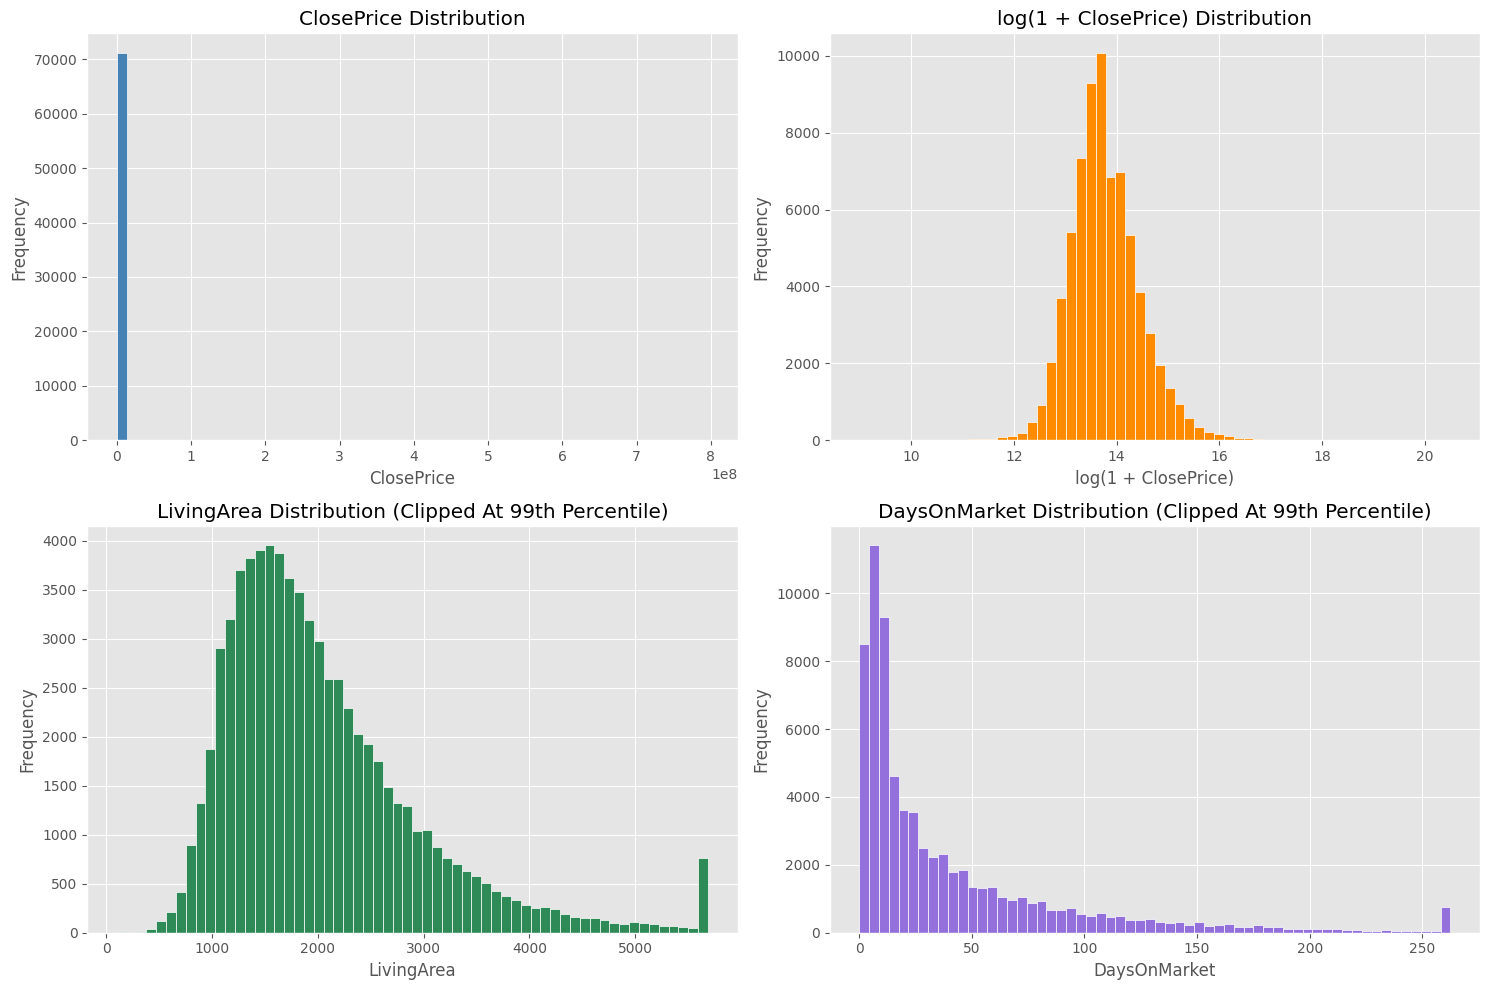

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

model_df["ClosePrice"].plot(
    kind="hist", bins=60, ax=axes[0, 0], color="steelblue", edgecolor="white"
)
axes[0, 0].set_title("ClosePrice Distribution")
axes[0, 0].set_xlabel("ClosePrice")

np.log1p(model_df["ClosePrice"]).plot(
    kind="hist", bins=60, ax=axes[0, 1], color="darkorange", edgecolor="white"
)
axes[0, 1].set_title("log(1 + ClosePrice) Distribution")
axes[0, 1].set_xlabel("log(1 + ClosePrice)")

model_df["LivingArea"].clip(upper=model_df["LivingArea"].quantile(0.99)).plot(
    kind="hist", bins=60, ax=axes[1, 0], color="seagreen", edgecolor="white"
)
axes[1, 0].set_title("LivingArea Distribution (Clipped At 99th Percentile)")
axes[1, 0].set_xlabel("LivingArea")

model_df["DaysOnMarket"].dropna().clip(
    upper=model_df["DaysOnMarket"].quantile(0.99)
).plot(kind="hist", bins=60, ax=axes[1, 1], color="mediumpurple", edgecolor="white")
axes[1, 1].set_title("DaysOnMarket Distribution (Clipped At 99th Percentile)")
axes[1, 1].set_xlabel("DaysOnMarket")

plt.tight_layout()
plt.show()


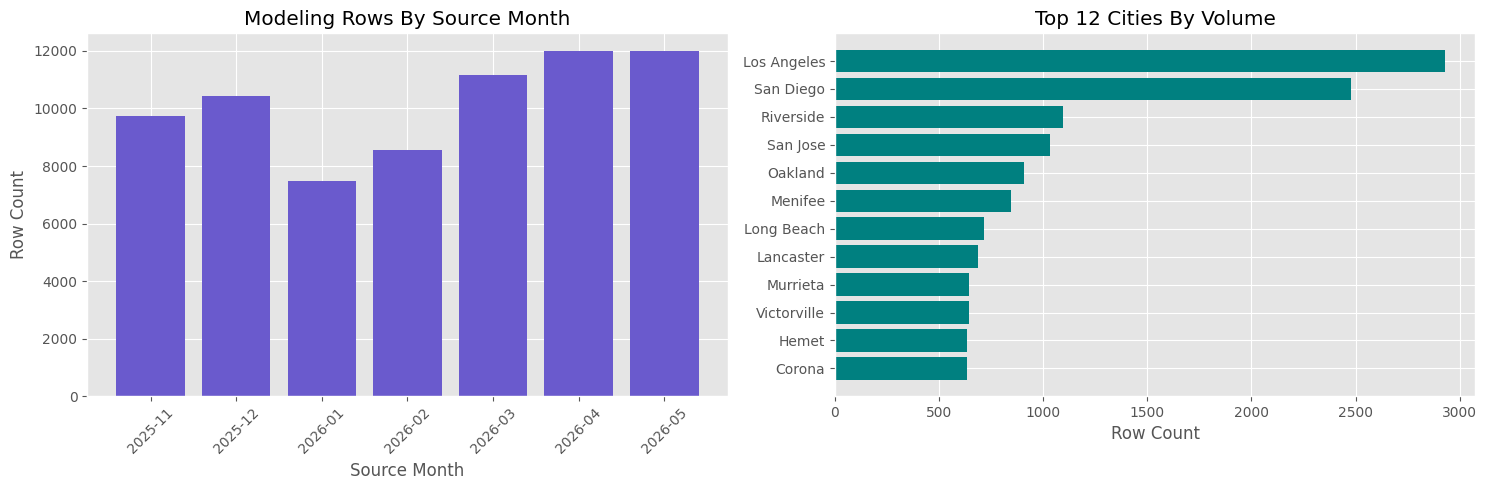

In [ ]:
monthly_counts = (
    model_df.groupby(model_df["source_month"].dt.to_period("M"))
    .size()
    .rename("row_count")
    .reset_index()
)
monthly_counts["source_month"] = monthly_counts["source_month"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(
    monthly_counts["source_month"], monthly_counts["row_count"], color="slateblue"
)
axes[0].set_title("Modeling Rows By Source Month")
axes[0].set_xlabel("Source Month")
axes[0].set_ylabel("Row Count")
axes[0].tick_params(axis="x", rotation=45)

city_counts = (
    model_df["City"].value_counts(dropna=True).head(12).sort_values(ascending=True)
)
axes[1].barh(city_counts.index, city_counts.values, color="teal")
axes[1].set_title("Top 12 Cities By Volume")
axes[1].set_xlabel("Row Count")

plt.tight_layout()
plt.show()


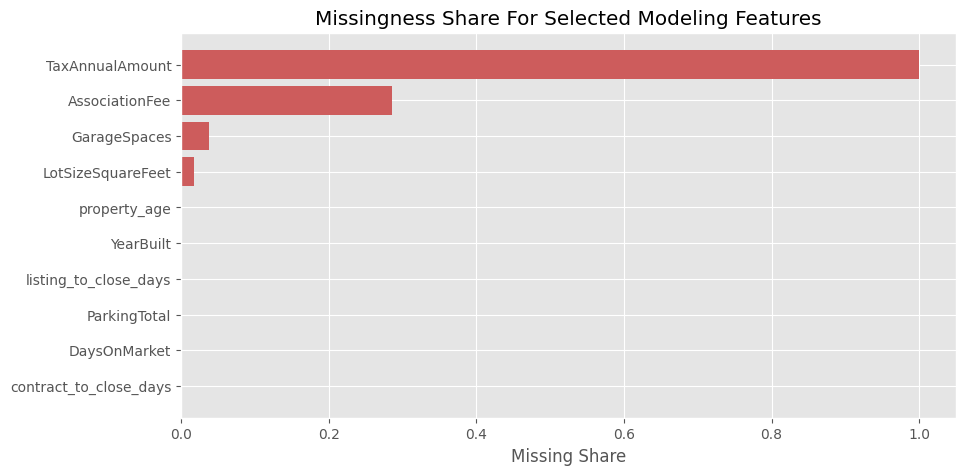

In [9]:
missing_pct = (
    model_df[
        [
            "LotSizeSquareFeet",
            "YearBuilt",
            "DaysOnMarket",
            "GarageSpaces",
            "ParkingTotal",
            "TaxAnnualAmount",
            "AssociationFee",
            "property_age",
            "contract_to_close_days",
            "listing_to_close_days",
        ]
    ]
    .isna()
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 5))
plt.barh(missing_pct.index, missing_pct.values, color="indianred")
plt.title("Missingness Share For Selected Modeling Features")
plt.xlabel("Missing Share")
plt.show()


## Define Features And Split Data

We include a mix of structural, time-based, price-related, and geographic features.


In [10]:
feature_cols = [
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "DaysOnMarket",
    "ParkingTotal",
    "GarageSpaces",
    "FireplacesTotal",
    "TaxAnnualAmount",
    "AssociationFee",
    "sale_to_list_ratio",
    "original_to_current_list_ratio",
    "list_price_per_sqft",
    "property_age",
    "close_year",
    "close_month_num",
    "close_quarter",
    "contract_to_close_days",
    "listing_to_close_days",
    "ViewYN",
    "WaterfrontYN",
    "BasementYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN",
    "City",
    "PostalCode",
    "CountyOrParish",
    "MLSAreaMajor",
    "ElementarySchoolDistrict",
    "HighSchoolDistrict",
    "Levels",
    "Stories",
]

target_col = "ClosePrice"

available_features = [col for col in feature_cols if col in model_df.columns]
X = model_df[available_features].copy()
y = model_df[target_col].copy()

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")


Train shape: (57086, 39)
Test shape: (14272, 39)
Numeric features: 33
Categorical features: 6


## Build Preprocessing Pipeline

We use:

- median imputation for numeric columns
- most-frequent imputation for categorical columns
- one-hot encoding for categorical columns


In [11]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


## Train Baseline Models

We compare three practical baselines:

1. `DummyRegressor` as a floor
2. `Ridge` as a regularized linear baseline
3. `RandomForestRegressor` as a non-linear tree baseline

For `Ridge` and `RandomForest`, we model the log-transformed target through `TransformedTargetRegressor` so that the model handles price skew more naturally.


In [14]:
models = {
    "DummyMedian": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", DummyRegressor(strategy="median")),
        ]
    ),
    "RidgeLogTarget": TransformedTargetRegressor(
        regressor=Pipeline(
            steps=[
                ("preprocess", preprocessor),
                ("model", Ridge(alpha=3.0)),
            ]
        ),
        func=np.log1p,
        inverse_func=np.expm1,
    ),
    "RandomForestLogTarget": TransformedTargetRegressor(
        regressor=Pipeline(
            steps=[
                ("preprocess", preprocessor),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=250,
                        max_depth=20,
                        min_samples_leaf=5,
                        n_jobs=-1,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        func=np.log1p,
        inverse_func=np.expm1,
    ),
}

results = []
predictions = {}
fitted_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append(
        {
            "model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
        }
    )
    predictions[model_name] = preds
    fitted_models[model_name] = model

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)


/opt/base-uv/.venv/lib/python3.13/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['FireplacesTotal' 'TaxAnnualAmount' 'ElementarySchoolDistrict']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/base-uv/.venv/lib/python3.13/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['FireplacesTotal' 'TaxAnnualAmount' 'ElementarySchoolDistrict']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/base-uv/.venv/lib/python3.13/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['FireplacesTotal' 'TaxAnnualAmount' 'ElementarySchoolDistrict']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/base-uv/.venv/lib/python3.13/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping f

,model,MAE,RMSE,R2
2,RandomForestLogTarget,95356.5366,7247443.5130,0.1479
0,DummyMedian,741550.0726,7864506.2970,-0.0034
1,RidgeLogTarget,39273151.7239,3796950251.3509,-233878.9214


## Compare Model Performance


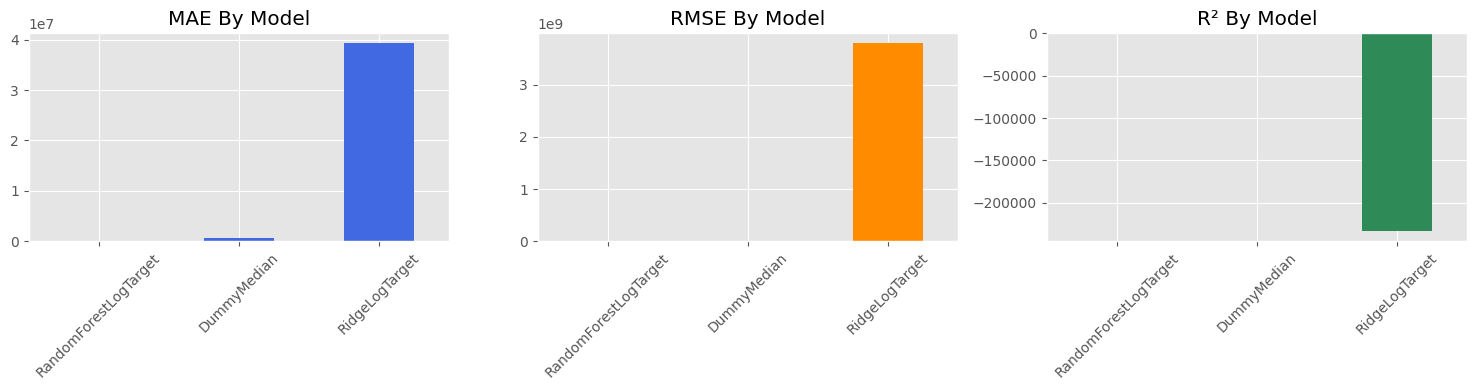

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

results_df.plot(
    x="model", y="MAE", kind="bar", legend=False, ax=axes[0], color="royalblue"
)
axes[0].set_title("MAE By Model")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

results_df.plot(
    x="model", y="RMSE", kind="bar", legend=False, ax=axes[1], color="darkorange"
)
axes[1].set_title("RMSE By Model")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

results_df.plot(
    x="model", y="R2", kind="bar", legend=False, ax=axes[2], color="seagreen"
)
axes[2].set_title("R² By Model")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Inspect The Best Model


In [17]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_preds = predictions[best_model_name]

comparison_df = pd.DataFrame(
    {
        "actual": y_test.values,
        "predicted": best_preds,
    },
    index=y_test.index,
)
comparison_df["residual"] = comparison_df["actual"] - comparison_df["predicted"]
comparison_df["abs_error"] = comparison_df["residual"].abs()

print(f"Best model: {best_model_name}")
display(comparison_df.head())


Best model: RandomForestLogTarget


,actual,predicted,residual,abs_error
22947,690000.0000,689948.8044,51.1956,51.1956
111209,860000.0000,859881.2274,118.7726,118.7726
22402,928000.0000,923628.2728,4371.7272,4371.7272
28779,840000.0000,839000.4181,999.5819,999.5819
76490,686000.0000,685582.1702,417.8298,417.8298


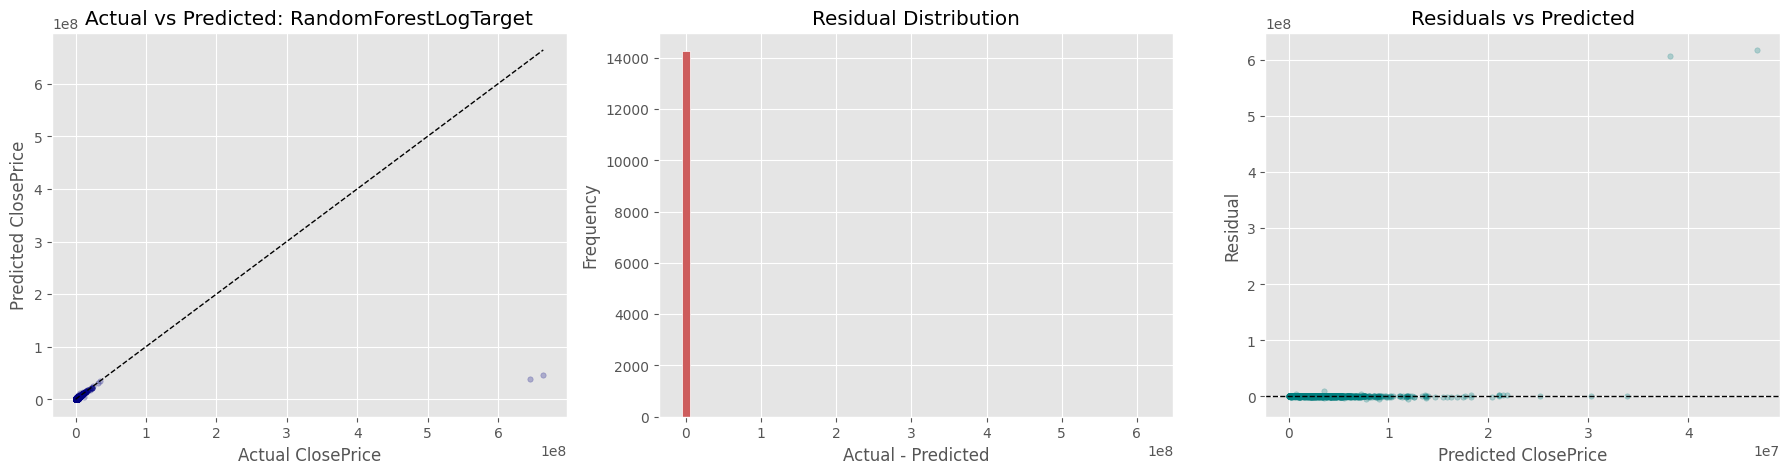

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(
    comparison_df["actual"],
    comparison_df["predicted"],
    alpha=0.25,
    s=15,
    color="navy",
)
max_price = max(comparison_df["actual"].max(), comparison_df["predicted"].max())
axes[0].plot([0, max_price], [0, max_price], color="black", linestyle="--", linewidth=1)
axes[0].set_title(f"Actual vs Predicted: {best_model_name}")
axes[0].set_xlabel("Actual ClosePrice")
axes[0].set_ylabel("Predicted ClosePrice")

comparison_df["residual"].plot(
    kind="hist", bins=60, ax=axes[1], color="indianred", edgecolor="white"
)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Actual - Predicted")

axes[2].scatter(
    comparison_df["predicted"],
    comparison_df["residual"],
    alpha=0.25,
    s=15,
    color="teal",
)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Residuals vs Predicted")
axes[2].set_xlabel("Predicted ClosePrice")
axes[2].set_ylabel("Residual")

plt.tight_layout()
plt.show()


## Error By Price Segment

This helps show whether the model struggles more on high-end homes than on middle-market homes.


/tmp/ipykernel_71518/1898448846.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comparison_df.groupby("actual_decile")


,actual_decile,row_count,median_actual,mean_abs_error,median_abs_error
0,"(11899.999, 440000.0]",1452,367500.0000,4662.9504,415.1464
1,"(440000.0, 564920.0]",1403,507000.0000,874.8277,225.7174
2,"(564920.0, 675000.0]",1462,620000.0000,1028.3456,230.4855
3,"(675000.0, 776278.0]",1392,725000.0000,1514.7432,228.6534
4,"(776278.0, 885500.0]",1427,830000.0000,1298.6159,257.0080
5,"(885500.0, 1050000.0]",1449,960000.0000,1732.2963,420.3151
6,"(1050000.0, 1287350.0]",1405,1170000.0000,1867.0691,627.9194
7,"(1287350.0, 1605000.0]",1428,1420000.0000,4328.9432,826.0071
8,"(1605000.0, 2350000.0]",1434,1875000.0000,5637.7773,1600.8317
9,"(2350000.0, 664250000.0]",1420,3257500.0000,935257.5931,7242.6435


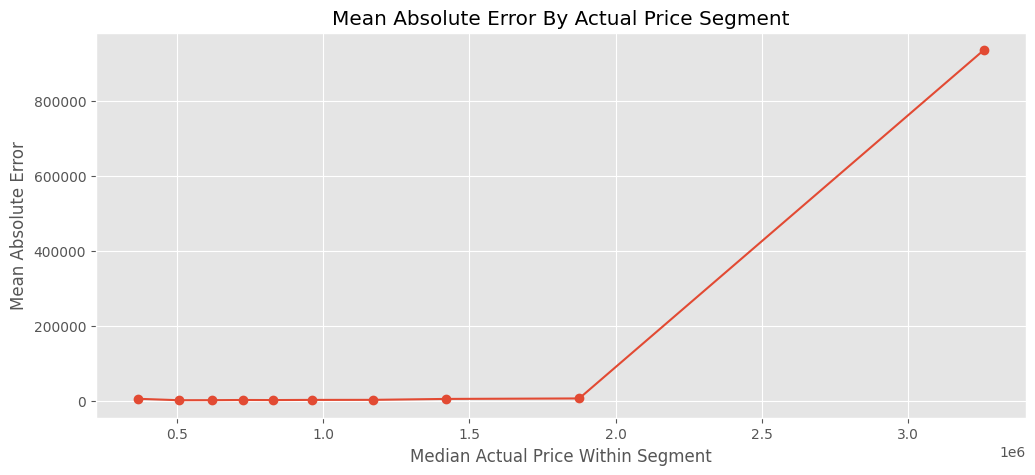

In [19]:
comparison_df["actual_decile"] = pd.qcut(
    comparison_df["actual"], q=10, duplicates="drop"
)

segment_error = (
    comparison_df.groupby("actual_decile")
    .agg(
        row_count=("actual", "size"),
        median_actual=("actual", "median"),
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
    )
    .reset_index()
)

display(segment_error)

plt.figure(figsize=(12, 5))
plt.plot(segment_error["median_actual"], segment_error["mean_abs_error"], marker="o")
plt.title("Mean Absolute Error By Actual Price Segment")
plt.xlabel("Median Actual Price Within Segment")
plt.ylabel("Mean Absolute Error")
plt.show()


## Feature Importance

For linear models, coefficients are harder to interpret after one-hot encoding and log-target transformation. For that reason, feature importance is shown for the random forest baseline if it was trained successfully.


,feature,importance
0,num__ListPrice,0.9776
13,num__sale_to_list_ratio,0.0222
1,num__OriginalListPrice,0.0002
15,num__list_price_per_sqft,0.0000
21,num__listing_to_close_days,0.0000
20,num__contract_to_close_days,0.0000
7,num__Latitude,0.0000
9,num__DaysOnMarket,0.0000
5,num__LotSizeSquareFeet,0.0000
8,num__Longitude,0.0000


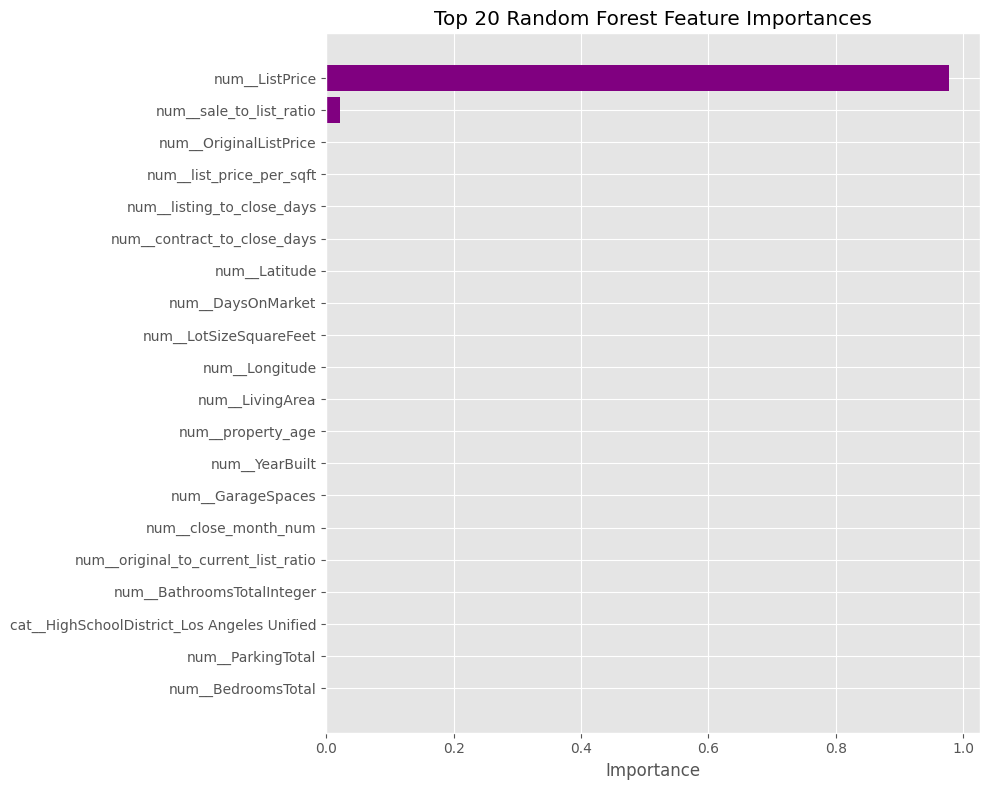

In [20]:
rf_name = "RandomForestLogTarget"

if rf_name in fitted_models:
    rf_wrapper = fitted_models[rf_name]
    rf_pipeline = rf_wrapper.regressor_
    rf_preprocessor = rf_pipeline.named_steps["preprocess"]
    rf_model = rf_pipeline.named_steps["model"]

    feature_names = rf_preprocessor.get_feature_names_out()
    importances = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": rf_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    top_importances = importances.head(20).sort_values("importance", ascending=True)
    display(importances.head(20))

    plt.figure(figsize=(10, 8))
    plt.barh(top_importances["feature"], top_importances["importance"], color="purple")
    plt.title("Top 20 Random Forest Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


## Geography Check On Best Model Errors

This quick map helps reveal whether the model's largest misses cluster geographically.


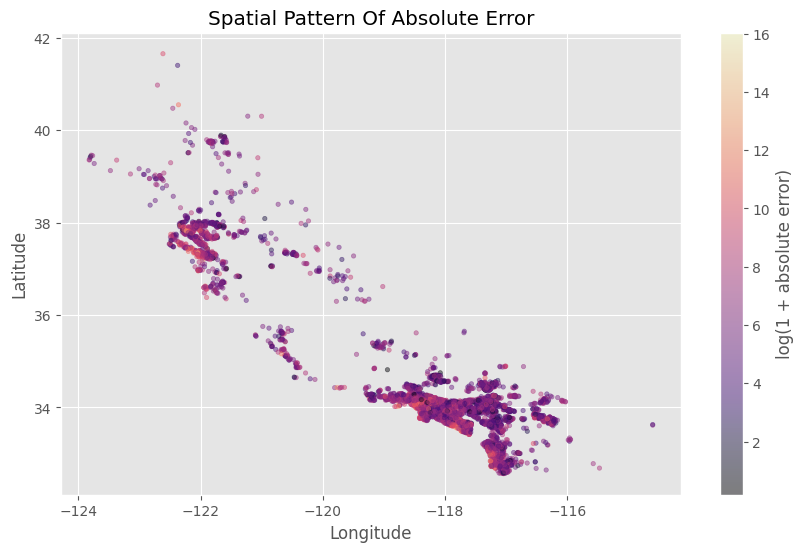

In [21]:
geo_error_df = model_df.loc[
    comparison_df.index, ["Latitude", "Longitude", "City"]
].copy()
geo_error_df = geo_error_df.join(comparison_df[["abs_error", "actual", "predicted"]])
geo_error_sample = geo_error_df.dropna(subset=["Latitude", "Longitude"]).sample(
    min(5000, geo_error_df.dropna(subset=["Latitude", "Longitude"]).shape[0]),
    random_state=RANDOM_STATE,
)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    geo_error_sample["Longitude"],
    geo_error_sample["Latitude"],
    c=np.log1p(geo_error_sample["abs_error"]),
    cmap="magma",
    s=10,
    alpha=0.45,
)
plt.title("Spatial Pattern Of Absolute Error")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(scatter, label="log(1 + absolute error)")
plt.show()


## Week 3 Summary Template

After you run the notebook, update this section with the actual best-model results.

Suggested points to report:

1. Final row count used for modeling after filtering.
2. Best-performing baseline model based on RMSE and MAE.
3. Whether the log-target setup improved stability.
4. The most important predictive features.
5. Whether errors grow meaningfully in the luxury segment.
6. Which feature engineering or model tuning ideas should be prioritized in Week 4.
